# 21 Compare Main Results dataset 2 (3 CNN Seeds)

This notebook collects the six saved experiment outputs for dataset 2 and builds the patch-level comparison tables and figures.


In [1]:
from pathlib import Path
import csv
import json
import shutil

import matplotlib.pyplot as plt

import pandas as pd

from IPython.display import display

# This helper keeps the notebook easy to run from the repo root or from notebooks/.
def find_repo_root(start_path: Path) -> Path:
    if (start_path / "raw_data").exists():
        return start_path
    if start_path.name == "notebooks" and (start_path.parent / "raw_data").exists():
        return start_path.parent
    raise FileNotFoundError("Could not find the FYP2 repo root.")

REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results"
NOTEBOOK_TAG = "21_compare_main_results_dataset2"
NOTEBOOK_RESULTS_DIR = RESULTS_DIR / NOTEBOOK_TAG
NOTEBOOK_FIGURES_DIR = NOTEBOOK_RESULTS_DIR / "figures"

# Compare notebooks are quick to rebuild, so clear only this notebook's old comparison outputs.
if NOTEBOOK_RESULTS_DIR.exists():
    shutil.rmtree(NOTEBOOK_RESULTS_DIR)
NOTEBOOK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RUN_TAGS = ["15_resnet50_baseline_dataset2", "16_resnet50_gan_dataset2", "17_efficientnetv2s_baseline_dataset2", "18_efficientnetv2s_gan_dataset2", "19_convnextv2nano_baseline_dataset2", "20_convnextv2nano_gan_dataset2"]

In [2]:
# This helper reads a CSV file into a plain list of rows.
def read_csv_rows(csv_path: Path):
    with csv_path.open("r", newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

# This helper writes a CSV file with a stable header.
def write_csv_rows(csv_path: Path, rows, fieldnames):
    if not rows:
        raise ValueError(f"No rows were provided for {csv_path.name}.")
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

# This helper writes one small JSON file with clean formatting.
def write_json(json_path: Path, data):
    json_path.parent.mkdir(parents=True, exist_ok=True)
    json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")

,run_tag,model_name,model_display_name,training_mode,seed_count,fold_count,run_count,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_precision,std_macro_precision,mean_macro_recall,std_macro_recall,mean_macro_f1,std_macro_f1
0,15_resnet50_baseline_dataset2,resnet50,ResNet-50,baseline,3,5,15,0.991274,0.003467,0.991482,0.002911,0.990785,0.004098,0.991482,0.002911,0.991100,0.003519
1,16_resnet50_gan_dataset2,resnet50,ResNet-50,gan,3,5,15,0.992395,0.004309,0.992588,0.003716,0.991971,0.004940,0.992588,0.003716,0.992243,0.004380
2,17_efficientnetv2s_baseline_dataset2,efficientnetv2s,EfficientNetV2-S,baseline,3,5,15,0.994279,0.002838,0.994440,0.002407,0.993919,0.003326,0.994440,0.002407,0.994163,0.002887
3,18_efficientnetv2s_gan_dataset2,efficientnetv2s,EfficientNetV2-S,gan,3,5,15,0.994961,0.001848,0.995025,0.001531,0.994710,0.002240,0.995025,0.001531,0.994855,0.001881
4,19_convnextv2nano_baseline_dataset2,convnextv2nano,ConvNeXtV2-Nano,baseline,3,5,15,0.936084,0.138508,0.926778,0.161388,0.928126,0.185774,0.926778,0.161388,0.913046,0.199529
5,20_convnextv2nano_gan_dataset2,convnextv2nano,ConvNeXtV2-Nano,gan,3,5,15,0.989240,0.004490,0.989077,0.004573,0.989065,0.004698,0.989077,0.004573,0.989014,0.004577


,class_name,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,run_tag
0,cocci,0.986845,0.009519,0.99295,0.003397,0.989854,0.003953,15_resnet50_baseline_dataset2
1,bacilli,0.994726,0.002505,0.990014,0.007343,0.992345,0.003086,15_resnet50_baseline_dataset2
2,cocci,0.988509,0.010829,0.993897,0.003569,0.991156,0.004938,16_resnet50_gan_dataset2
3,bacilli,0.995433,0.002677,0.99128,0.008417,0.993329,0.003822,16_resnet50_gan_dataset2
4,cocci,0.991152,0.007253,0.995571,0.00166,0.99334,0.003265,17_efficientnetv2s_baseline_dataset2
5,bacilli,0.996685,0.00123,0.993309,0.005555,0.994985,0.00251,17_efficientnetv2s_baseline_dataset2
6,cocci,0.992834,0.005601,0.995437,0.002509,0.99412,0.002131,18_efficientnetv2s_gan_dataset2
7,bacilli,0.996586,0.001881,0.994612,0.004261,0.99559,0.001631,18_efficientnetv2s_gan_dataset2
8,cocci,0.922251,0.255248,0.860421,0.324895,0.869737,0.310504,19_convnextv2nano_baseline_dataset2
9,bacilli,0.934,0.141928,0.993136,0.004574,0.956355,0.088851,19_convnextv2nano_baseline_dataset2


,model_name,accuracy_gain,balanced_accuracy_gain,macro_precision_gain,macro_recall_gain,macro_f1_gain
0,convnextv2nano,0.053156,0.062299,0.060939,0.062299,0.075968
1,efficientnetv2s,0.000682,0.000585,0.000791,0.000585,0.000692
2,resnet50,0.001121,0.001106,0.001186,0.001106,0.001143


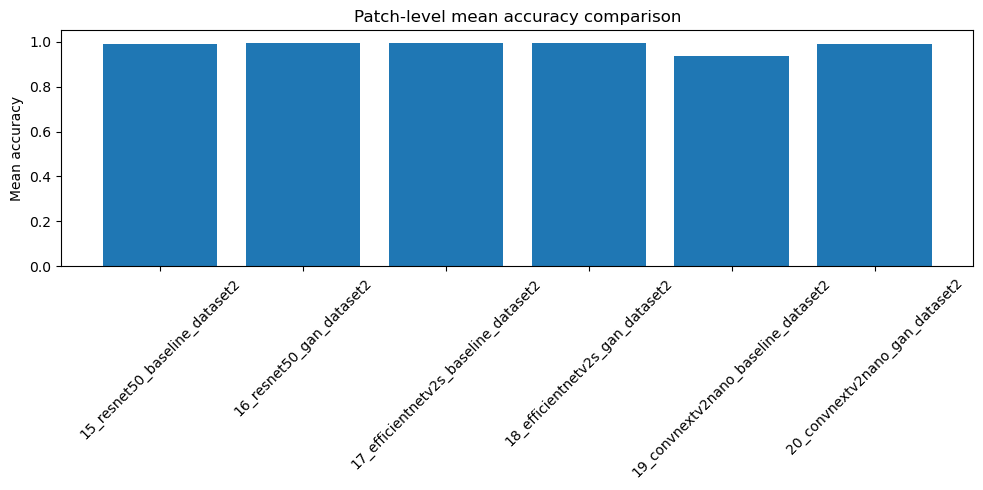

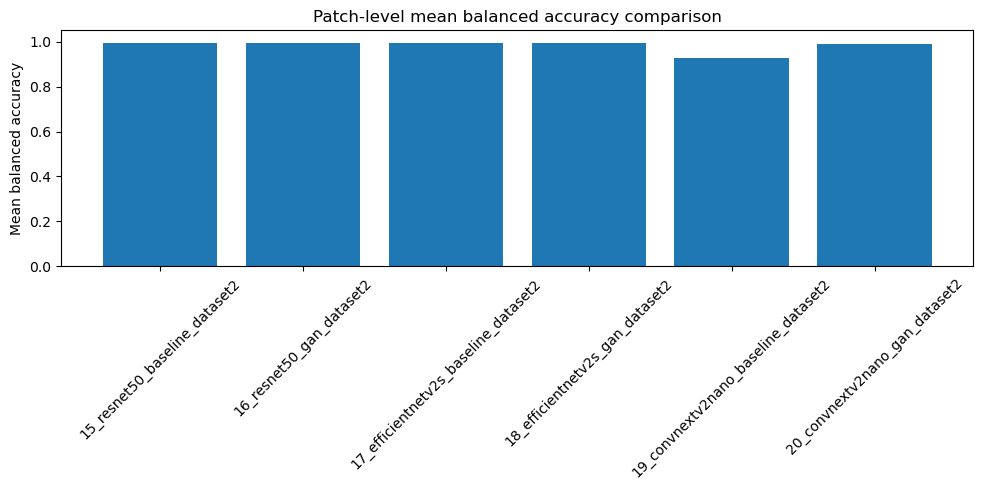

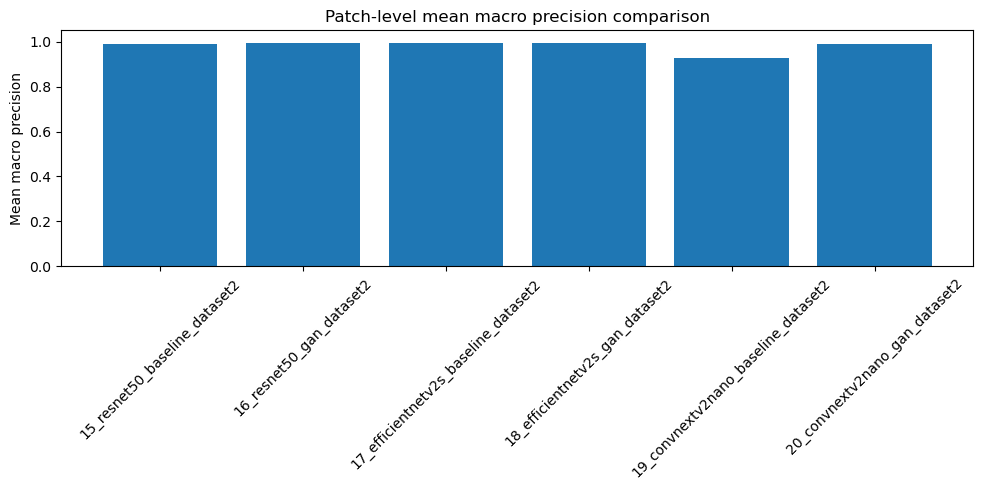

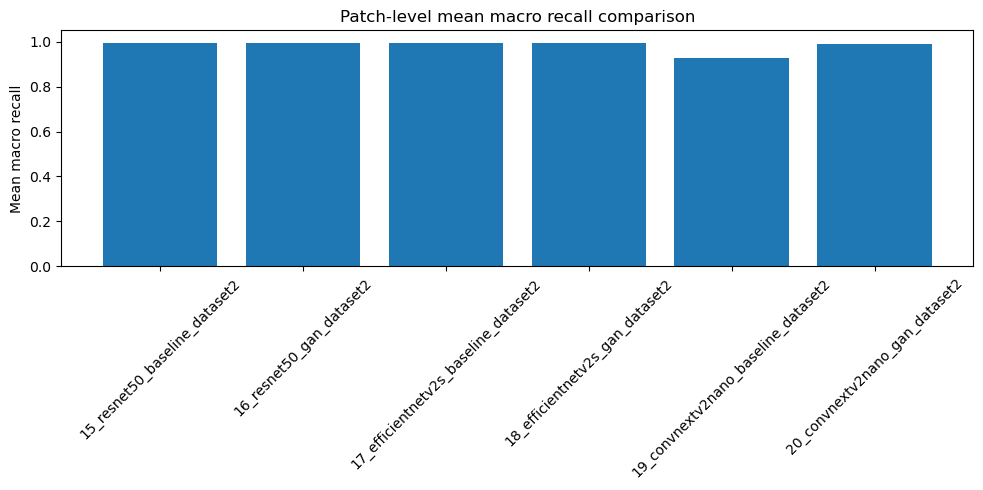

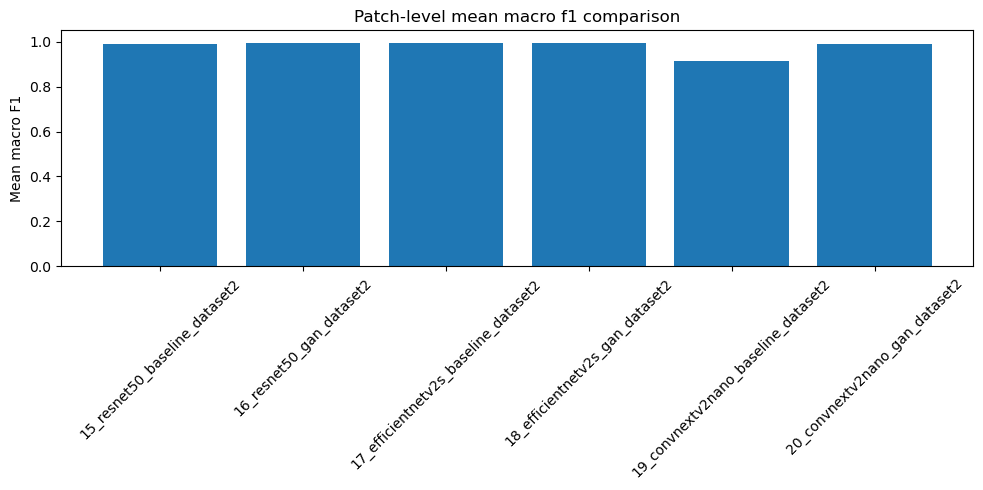

,run_tag,class_name,metric_name,metric_value
0,15_resnet50_baseline_dataset2,cocci,precision,0.986845
1,15_resnet50_baseline_dataset2,cocci,recall,0.992950
2,15_resnet50_baseline_dataset2,cocci,f1,0.989854
3,15_resnet50_baseline_dataset2,bacilli,precision,0.994726
4,15_resnet50_baseline_dataset2,bacilli,recall,0.990014
5,15_resnet50_baseline_dataset2,bacilli,f1,0.992345
6,16_resnet50_gan_dataset2,cocci,precision,0.988509
7,16_resnet50_gan_dataset2,cocci,recall,0.993897
8,16_resnet50_gan_dataset2,cocci,f1,0.991156
9,16_resnet50_gan_dataset2,bacilli,precision,0.995433


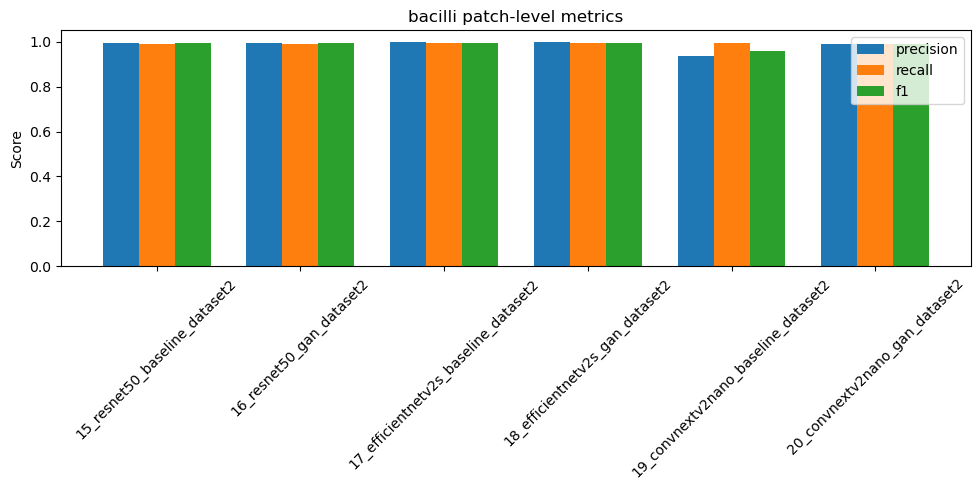

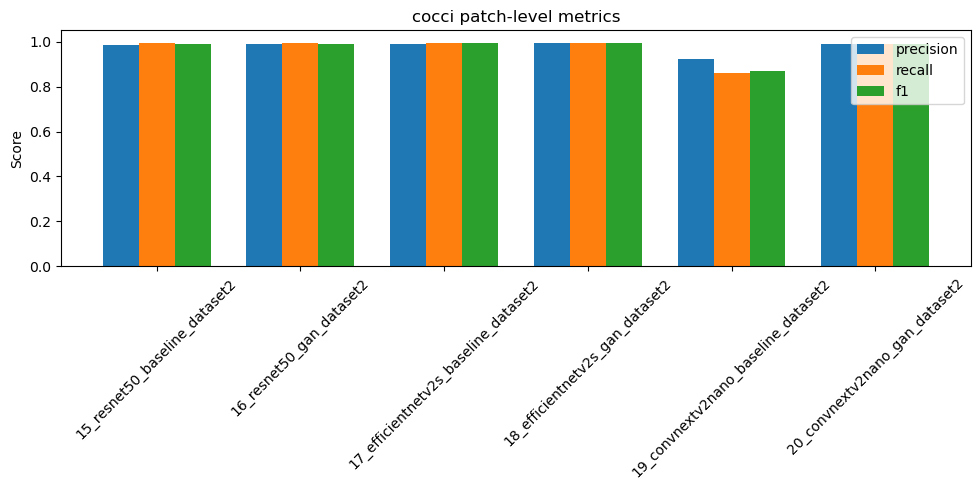

In [3]:
# We read the saved outputs from the six experiment notebooks.
model_rows = []
class_rows = []
round_rows = []

for run_tag in RUN_TAGS:
    summary_path = RESULTS_DIR / run_tag / "summary.json"
    class_metrics_path = RESULTS_DIR / run_tag / "class_metrics_mean.csv"
    round_metrics_path = RESULTS_DIR / run_tag / "round_metrics.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing summary for {run_tag}: {summary_path}")

    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    model_rows.append({
        "run_tag": run_tag,
        "model_name": summary["model_name"],
        "model_display_name": summary["model_display_name"],
        "training_mode": summary["training_mode"],
        "seed_count": summary.get("seed_count", ""),
        "fold_count": summary.get("fold_count", ""),
        "run_count": summary.get("run_count", ""),
        "mean_accuracy": summary["mean_accuracy"],
        "std_accuracy": summary["std_accuracy"],
        "mean_balanced_accuracy": summary["mean_balanced_accuracy"],
        "std_balanced_accuracy": summary["std_balanced_accuracy"],
        "mean_macro_precision": summary["mean_macro_precision"],
        "std_macro_precision": summary["std_macro_precision"],
        "mean_macro_recall": summary["mean_macro_recall"],
        "std_macro_recall": summary["std_macro_recall"],
        "mean_macro_f1": summary["mean_macro_f1"],
        "std_macro_f1": summary["std_macro_f1"],
    })

    for row in read_csv_rows(class_metrics_path):
        row["run_tag"] = run_tag
        class_rows.append(row)

    for row in read_csv_rows(round_metrics_path):
        row["run_tag"] = run_tag
        round_rows.append(row)

write_csv_rows(NOTEBOOK_RESULTS_DIR / "model_comparison.csv", model_rows, list(model_rows[0].keys()))
write_csv_rows(NOTEBOOK_RESULTS_DIR / "class_comparison.csv", class_rows, list(class_rows[0].keys()))
write_csv_rows(NOTEBOOK_RESULTS_DIR / "per_round_metrics.csv", round_rows, list(round_rows[0].keys()))

backbone_lookup = {}
for row in model_rows:
    model_name = row["model_name"]
    if model_name not in backbone_lookup:
        backbone_lookup[model_name] = {}
    backbone_lookup[model_name][row["training_mode"]] = row
gain_rows = []
for model_name in sorted(backbone_lookup):
    if "baseline" in backbone_lookup[model_name] and "gan" in backbone_lookup[model_name]:
        baseline = backbone_lookup[model_name]["baseline"]
        gan = backbone_lookup[model_name]["gan"]
        gain_rows.append({
            "model_name": model_name,
            "accuracy_gain": round(float(gan["mean_accuracy"]) - float(baseline["mean_accuracy"]), 6),
            "balanced_accuracy_gain": round(float(gan["mean_balanced_accuracy"]) - float(baseline["mean_balanced_accuracy"]), 6),
            "macro_precision_gain": round(float(gan["mean_macro_precision"]) - float(baseline["mean_macro_precision"]), 6),
            "macro_recall_gain": round(float(gan["mean_macro_recall"]) - float(baseline["mean_macro_recall"]), 6),
            "macro_f1_gain": round(float(gan["mean_macro_f1"]) - float(baseline["mean_macro_f1"]), 6),
        })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "gain_summary.csv", gain_rows, list(gain_rows[0].keys()))
write_json(NOTEBOOK_RESULTS_DIR / "summary.json", {"notebook_tag": NOTEBOOK_TAG, "run_tags": RUN_TAGS})

model_df = pd.DataFrame(model_rows)
class_df = pd.DataFrame(class_rows)
gain_df = pd.DataFrame(gain_rows)
display(model_df)
display(class_df)
display(gain_df)

# These figures are shown in the notebook and saved to disk.
metric_plot_specs = [
    ("mean_accuracy", "accuracy_comparison.png", "Mean accuracy"),
    ("mean_balanced_accuracy", "balanced_accuracy_comparison.png", "Mean balanced accuracy"),
    ("mean_macro_precision", "macro_precision_comparison.png", "Mean macro precision"),
    ("mean_macro_recall", "macro_recall_comparison.png", "Mean macro recall"),
    ("mean_macro_f1", "macro_f1_comparison.png", "Mean macro F1"),
]
for metric_name, file_name, axis_label in metric_plot_specs:
    fig, axis = plt.subplots(figsize=(10, 5))
    axis.bar(model_df["run_tag"], model_df[metric_name])
    axis.set_ylim(0.0, 1.05)
    axis.set_ylabel(axis_label)
    axis.set_title(f"Patch-level {axis_label.lower()} comparison")
    axis.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(NOTEBOOK_FIGURES_DIR / file_name, dpi=200)
    plt.show()

class_plot_rows = []
for _, row in class_df.iterrows():
    class_plot_rows.append({
        "run_tag": row["run_tag"],
        "class_name": row["class_name"],
        "metric_name": "precision",
        "metric_value": float(row["mean_precision"]),
    })
    class_plot_rows.append({
        "run_tag": row["run_tag"],
        "class_name": row["class_name"],
        "metric_name": "recall",
        "metric_value": float(row["mean_recall"]),
    })
    class_plot_rows.append({
        "run_tag": row["run_tag"],
        "class_name": row["class_name"],
        "metric_name": "f1",
        "metric_value": float(row["mean_f1"]),
    })
class_plot_df = pd.DataFrame(class_plot_rows)
display(class_plot_df)
for class_name in sorted(class_plot_df["class_name"].unique()):
    current = class_plot_df[class_plot_df["class_name"] == class_name]
    pivot_df = current.pivot(index="run_tag", columns="metric_name", values="metric_value").reset_index()
    fig, axis = plt.subplots(figsize=(10, 5))
    x_positions = range(len(pivot_df))
    metric_names = ["precision", "recall", "f1"]
    bar_width = 0.25
    for metric_index, metric_name in enumerate(metric_names):
        offsets = [position + ((metric_index - 1) * bar_width) for position in x_positions]
        axis.bar(offsets, pivot_df[metric_name], width=bar_width, label=metric_name)
    axis.set_xticks(list(x_positions))
    axis.set_xticklabels(pivot_df["run_tag"], rotation=45)
    axis.set_ylim(0.0, 1.05)
    axis.set_ylabel("Score")
    axis.set_title(f"{class_name} patch-level metrics")
    axis.legend()
    fig.tight_layout()
    fig.savefig(NOTEBOOK_FIGURES_DIR / f"{class_name}_class_metrics.png", dpi=200)
    plt.show()